# DAISEE Dataset - In-Depth Overview

This notebook provides a comprehensive analysis of the **DAISEE (Dataset for Automatic Student Engagement Identification)** dataset. It explains the dataset structure, detailed feature descriptions, and visualizations for each feature category.

## Dataset Overview

The DAISEE dataset is designed for automatic student engagement detection from facial expressions and head pose data. It contains:
- **8,503 video samples** (after filtering failed videos)
- **150 timesteps** per sample (sequence of facial expressions over time)
- **78 features** per timestep extracted from facial landmarks
- **4 target labels**: Boredom, Engagement, Confusion, Frustration (each with 3 levels: 0=Low, 1=Medium, 2=High)

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Load the dataset
with open('../daisee_features_v2/complete_dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

X = dataset['X']
y = dataset['y']
feature_names = dataset['feature_names']
video_paths = dataset['video_paths']

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Sequence length (timesteps): {X.shape[1]}")
print(f"Number of features: {X.shape[2]}")
print(f"Number of failed videos: {len(dataset['failed_videos'])}")

Dataset shape: (8503, 150, 78)
Number of samples: 8503
Sequence length (timesteps): 150
Number of features: 78
Number of failed videos: 68


## Target Labels Distribution

The dataset has 4 multi-class classification targets. Each label has 3 levels:
- **0**: Low
- **1**: Medium  
- **2**: High

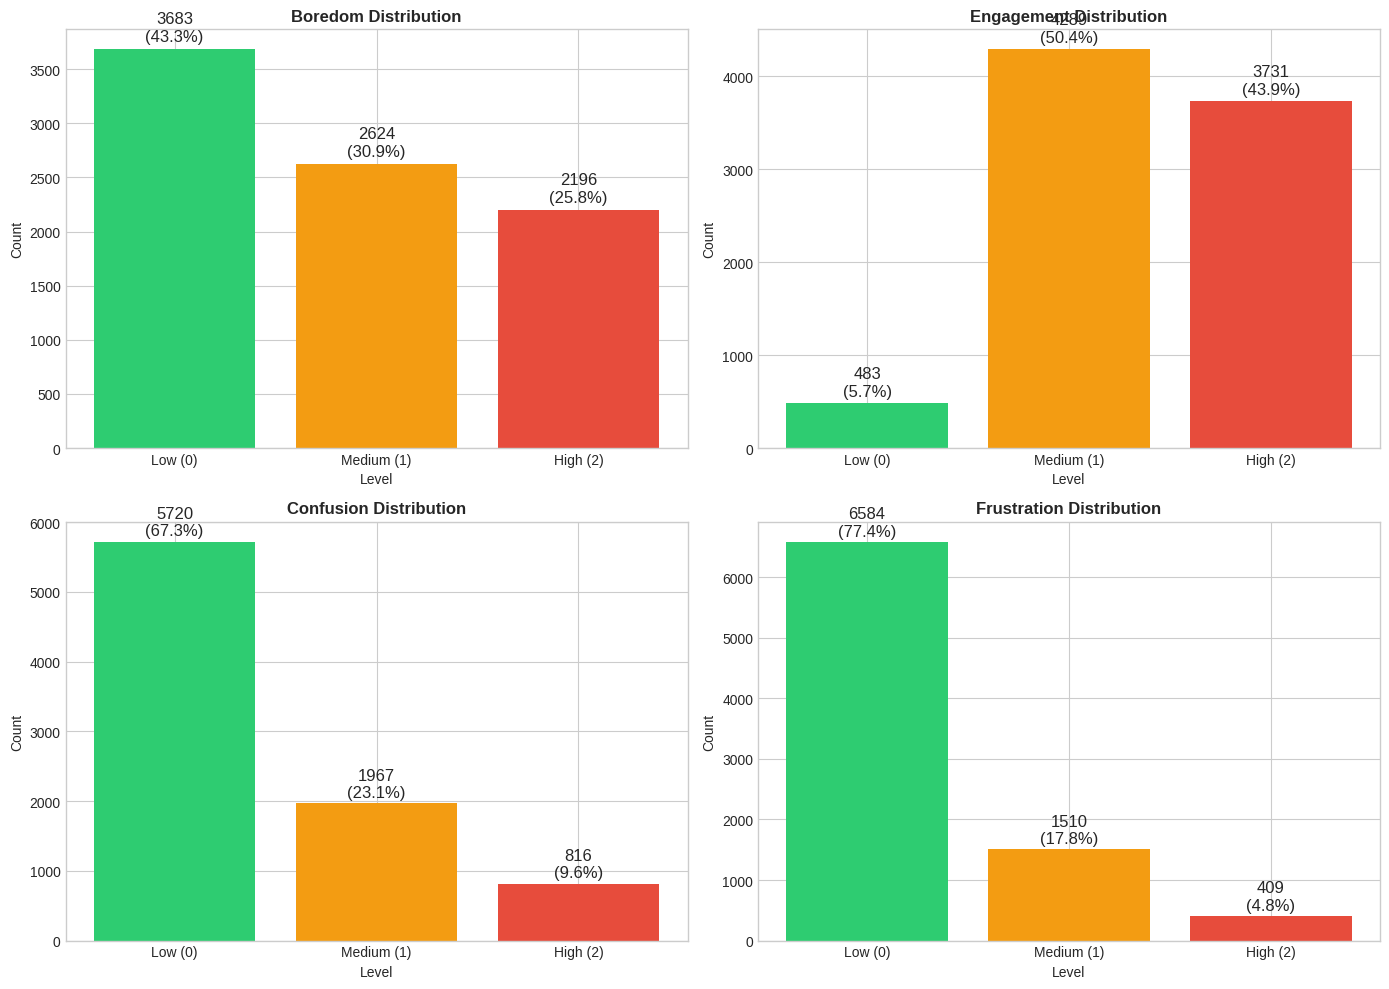

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labels = ['boredom', 'engagement', 'confusion', 'frustration']

for idx, (ax, label) in enumerate(zip(axes.flat, labels)):
    values = y[label]
    unique, counts = np.unique(values, return_counts=True)
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    bars = ax.bar(['Low (0)', 'Medium (1)', 'High (2)'], counts, color=colors)
    ax.set_title(f'{label.capitalize()} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('Level')
    
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{count}\n({100*count/len(values):.1f}%)', 
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
# plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Categories

The 78 features are organized into the following categories:

### 1. Facial Action Units (AU) - Indices 0-51
52 blendshape features representing facial muscle movements based on the Facial Action Coding System (FACS). These are extracted from MediaPipe Face Mesh.

### 2. Head Pose - Indices 52-57
6 features describing head orientation and position in 3D space.

### 3. Gaze Direction - Indices 58-63
6 features describing eye gaze direction (left eye, right eye, and combined).

### 4. Derived Activity Features - Indices 64-69
6 features representing aggregated activity and symmetry measures for eyebrows, eyes, and mouth.

### 5. Engagement Indicators - Indices 70-73
4 features indicating emotional/engagement states derived from facial movements.

### 6. Aggregate Features - Indices 74-77
4 higher-level features summarizing overall facial dynamics.

## Detailed Feature Descriptions

### 1. Facial Action Units (AUs) - 52 features

These represent the activation levels of specific facial muscles:

**Eyebrow AUs (0-5):**
- `_neutral`: Neutral face baseline
- `browDownLeft/Right`: Lowering of eyebrow (anger, concentration)
- `browInnerUp`: Inner eyebrow raised (sadness, surprise)
- `browOuterUpLeft/Right`: Outer eyebrow raised (sadness)

**Cheek AUs (6-8):**
- `cheekPuff`: Cheeks puffed out
- `cheekSquintLeft/Right`: Cheek squint (indicates genuine smile)

**Eye AUs (9-22):**
- `eyeBlinkLeft/Right`: Eye blinking
- `eyeLookDown/Up/In/Out`: Eye gaze direction
- `eyeSquintLeft/Right`: Eye squinting
- `eyeWideLeft/Right`: Eyes widened

**Jaw AUs (23-26):**
- `jawForward`: Jaw moved forward
- `jawLeft/Right`: Jaw shifted laterally
- `jawOpen`: Jaw opened

**Mouth AUs (27-51):**
- Various mouth movements including smiles, frowns, pucker, funnel, etc.
- Left/Right variants for asymmetric expressions

**Nose AUs (50-51):**
- `noseSneerLeft/Right`: Nostril flaring

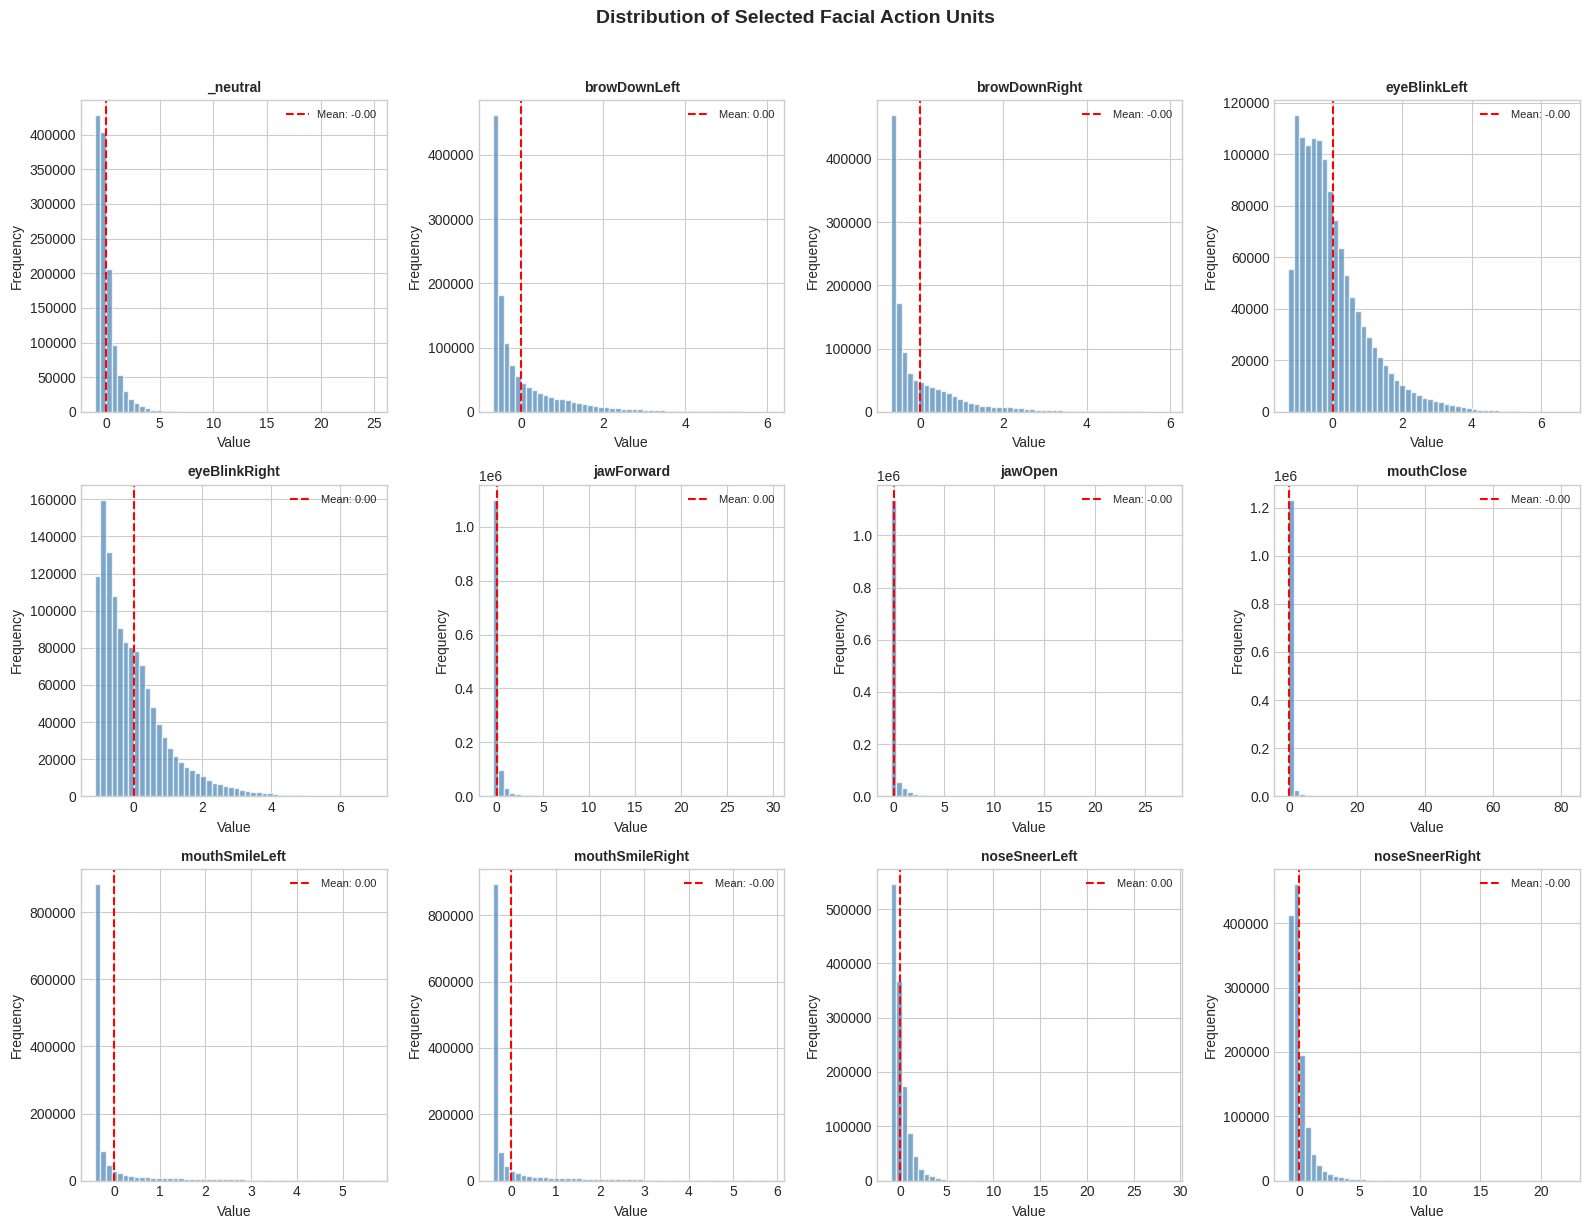

In [5]:
# Visualize Facial Action Units - subset of most important ones
au_features = feature_names[0:52]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
selected_aus = [0, 1, 2, 9, 10, 23, 25, 27, 44, 45, 50, 51]

for idx, (ax, au_idx) in enumerate(zip(axes.flat, selected_aus)):
    feature_data = X[:, :, au_idx].flatten()
    ax.hist(feature_data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(f'{feature_names[au_idx]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(feature_data), color='red', linestyle='--', label=f'Mean: {np.mean(feature_data):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Selected Facial Action Units', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('facial_action_units_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Head Pose Features - 6 features

**Indices 52-57:**
- `head_pitch`: Vertical head rotation (nodding up/down)
- `head_yaw`: Horizontal head rotation (turning left/right)
- `head_roll`: Tilted head rotation (ear to shoulder)
- `head_translation_x`: Head movement left/right
- `head_translation_y`: Head movement up/down
- `head_translation_z`: Head movement forward/backward

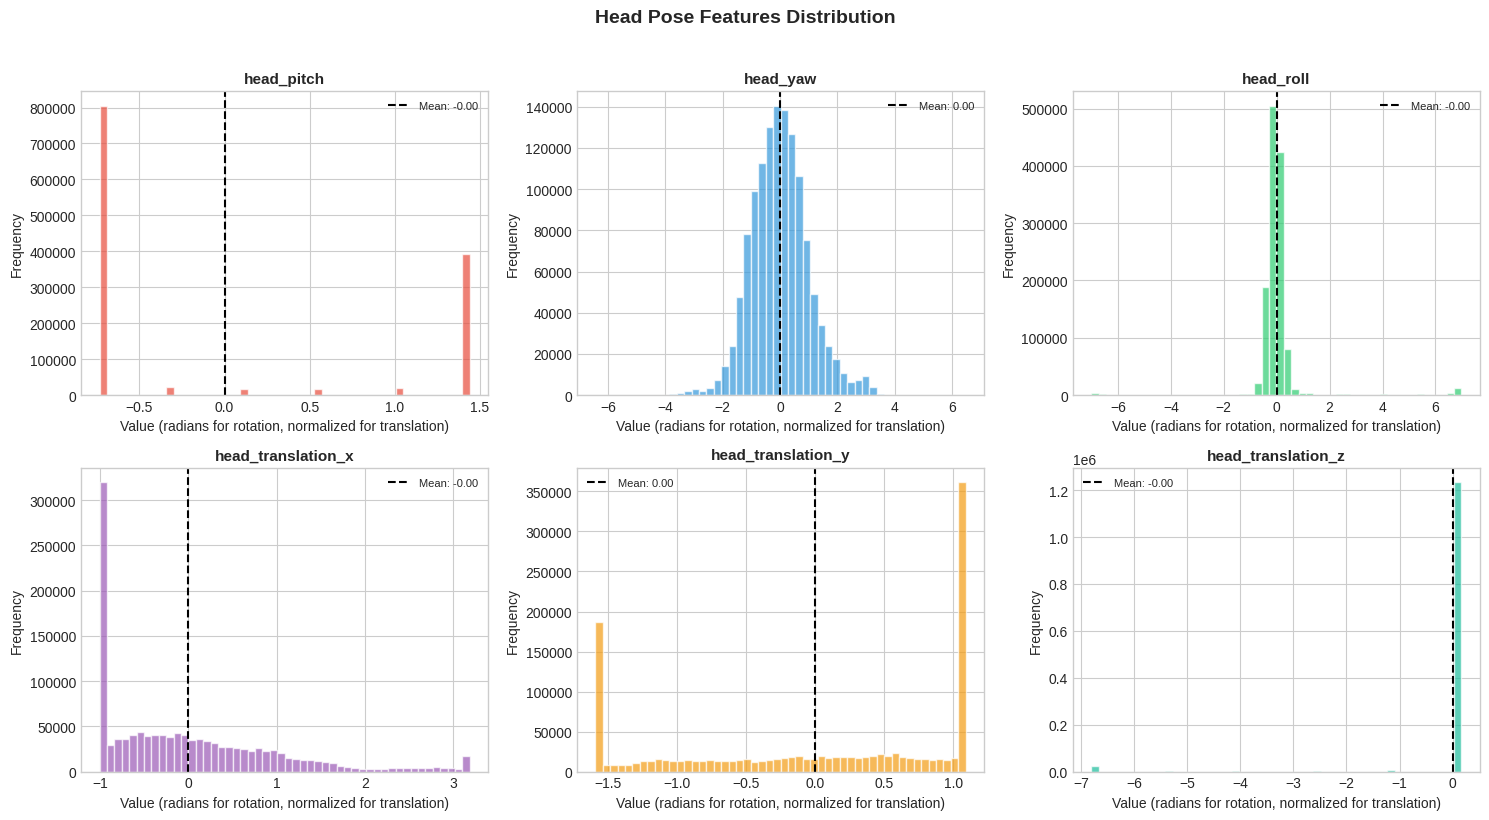

In [ ]:
# Visualize Head Pose features
head_pose_features = feature_names[52:58]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for idx, (ax, feat_idx) in enumerate(zip(axes.flat, range(52, 58))):
    feature_data = X[:, :, feat_idx].flatten()
    ax.hist(feature_data, bins=50, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.set_title(f'{feature_names[feat_idx]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value (radians for rotation, normalized for translation)')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(feature_data), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(feature_data):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Head Pose Features Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('head_pose_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Gaze Direction Features - 6 features

**Indices 58-63:**
- `left_gaze_horizontal/vertical`: Direction of left eye gaze
- `right_gaze_horizontal/vertical`: Direction of right eye gaze
- `combined_gaze_horizontal/vertical`: Average gaze direction from both eyes

Positive values indicate right/up gaze, negative values indicate left/down gaze.

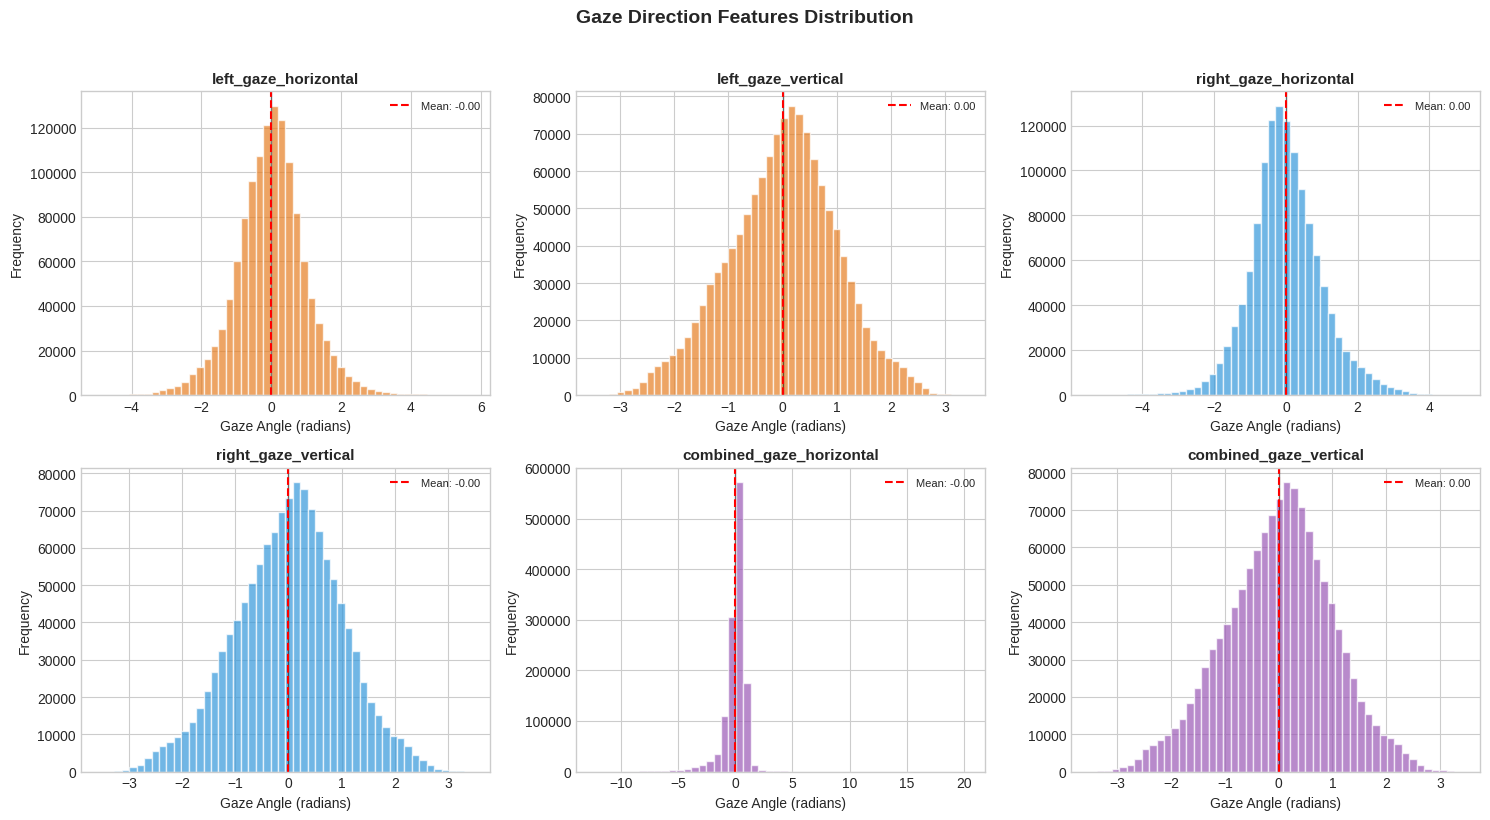

In [6]:
# Visualize Gaze Direction features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#e67e22', '#e67e22', '#3498db', '#3498db', '#9b59b6', '#9b59b6']

for idx, (ax, feat_idx) in enumerate(zip(axes.flat, range(58, 64))):
    feature_data = X[:, :, feat_idx].flatten()
    ax.hist(feature_data, bins=50, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.set_title(f'{feature_names[feat_idx]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Gaze Angle (radians)')
    ax.set_ylabel('Frequency')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(np.mean(feature_data), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(feature_data):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Gaze Direction Features Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gaze_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Derived Activity Features - 6 features

**Indices 64-69:**
- `eyebrow_activity`: Overall movement intensity of eyebrows
- `eye_activity`: Overall eye movement intensity
- `mouth_activity`: Overall mouth movement intensity
- `eyebrow_symmetry`: Symmetry measure between left and right eyebrows
- `eye_symmetry`: Symmetry measure between left and right eyes
- `mouth_symmetry`: Symmetry measure between left and right mouth

Symmetry values near 0 indicate symmetric expressions. Negative values indicate asymmetry.

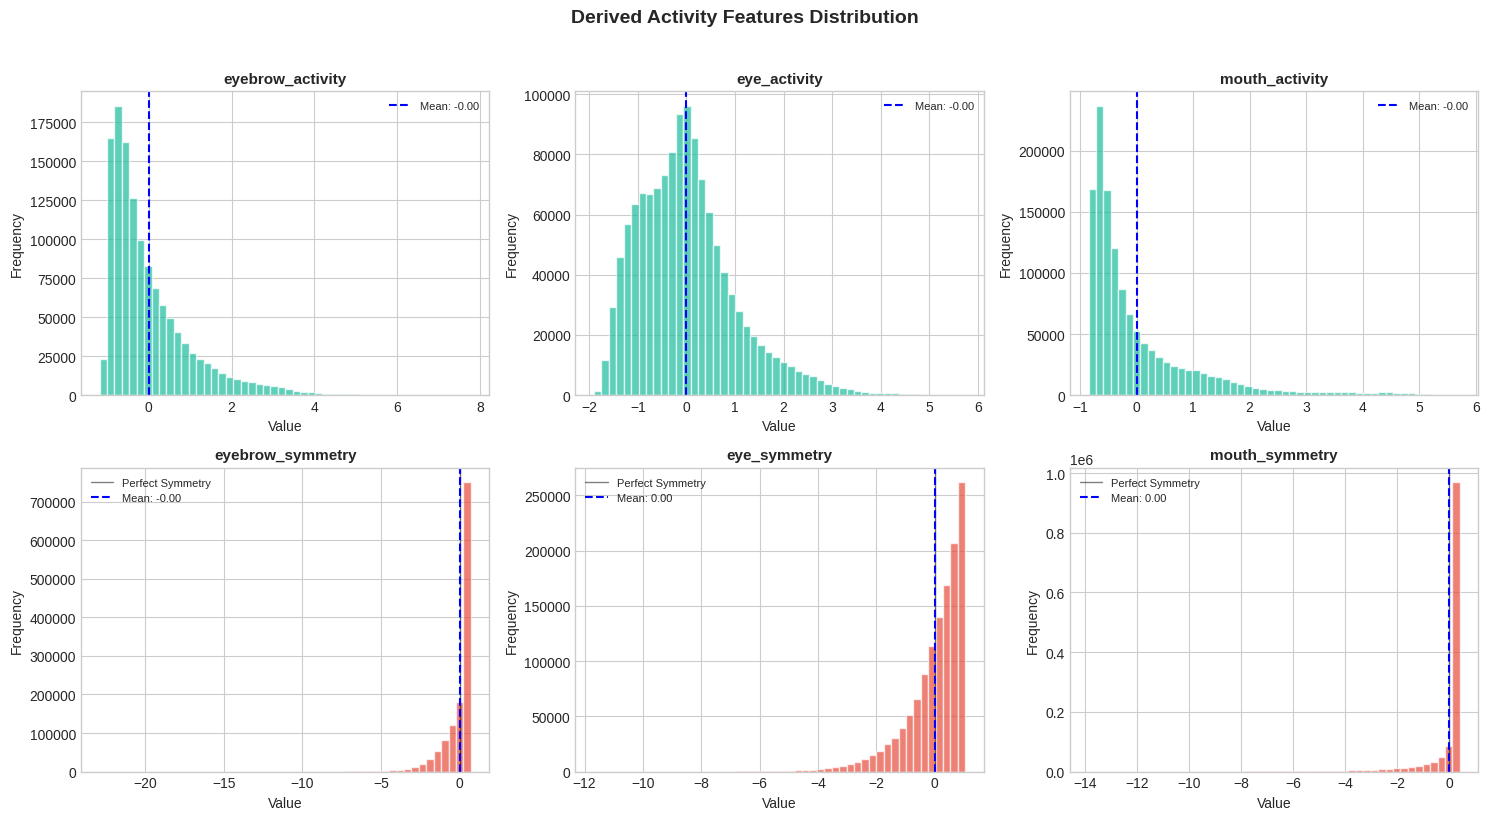

In [7]:
# Visualize Derived Activity Features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#1abc9c', '#1abc9c', '#1abc9c', '#e74c3c', '#e74c3c', '#e74c3c']

for idx, (ax, feat_idx) in enumerate(zip(axes.flat, range(64, 70))):
    feature_data = X[:, :, feat_idx].flatten()
    ax.hist(feature_data, bins=50, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.set_title(f'{feature_names[feat_idx]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    if 'symmetry' in feature_names[feat_idx]:
        ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Perfect Symmetry')
    ax.axvline(np.mean(feature_data), color='blue', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(feature_data):.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Derived Activity Features Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('derived_activity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Engagement Indicators - 4 features

**Indices 70-73:**
- `confusion_indicator`: Derived from specific facial patterns (brow lowering, mouth opening)
- `frustration_indicator`: Derived from tension patterns (lip press, brow lowering)
- `boredom_indicator`: Derived from reduced facial activity
- `engagement_indicator`: Derived from overall facial animation level

These are pre-computed indicators based on research in affective computing.

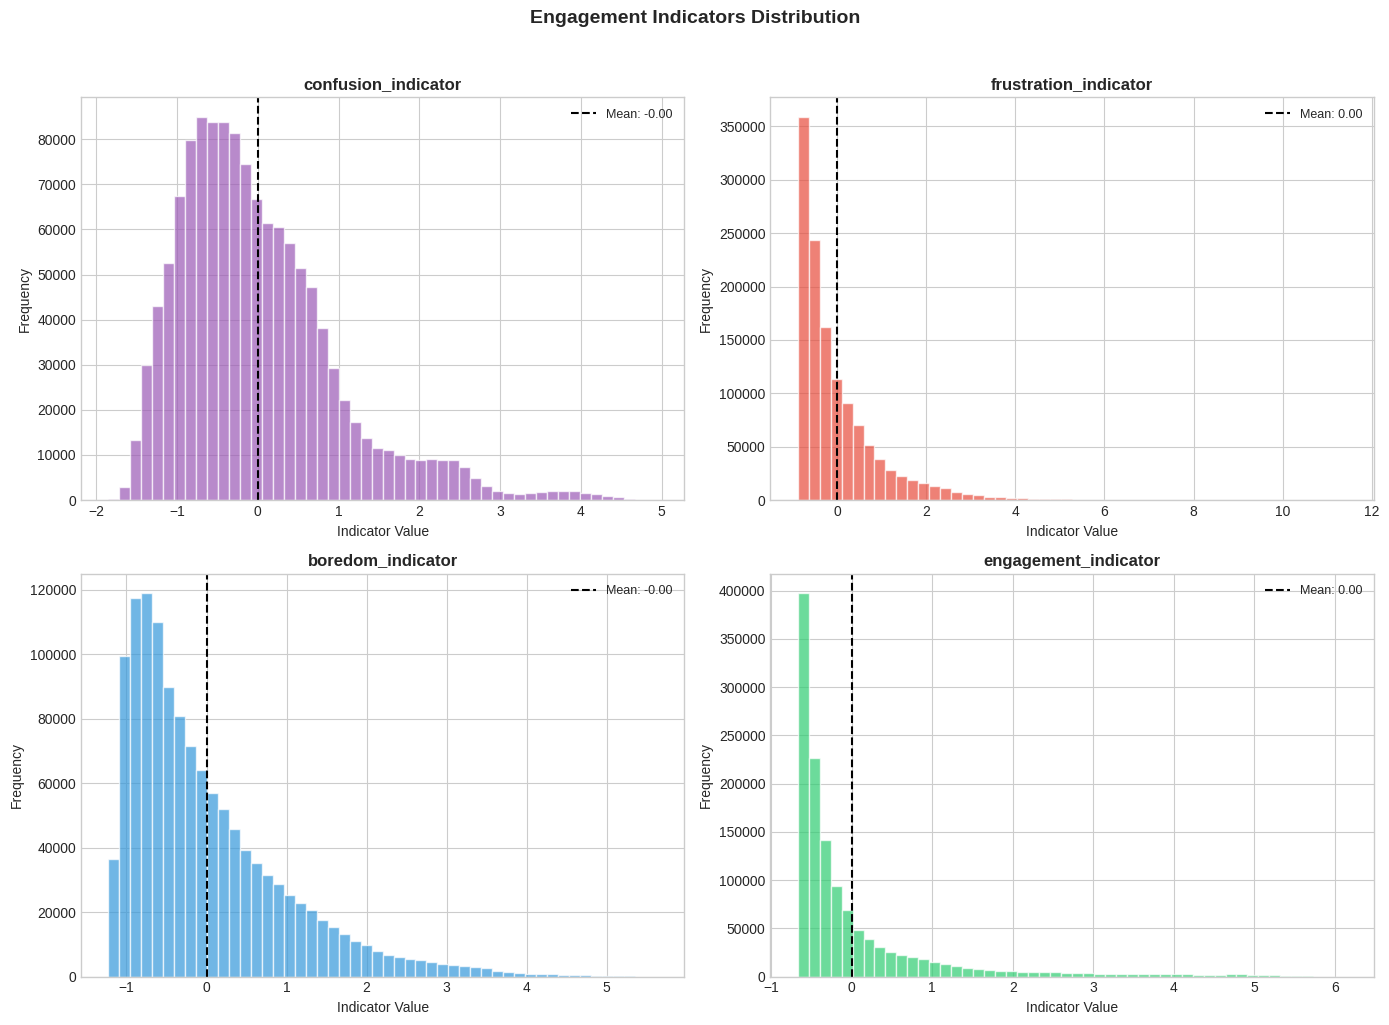

In [8]:
# Visualize Engagement Indicators
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#9b59b6', '#e74c3c', '#3498db', '#2ecc71']

for idx, (ax, feat_idx) in enumerate(zip(axes.flat, range(70, 74))):
    feature_data = X[:, :, feat_idx].flatten()
    ax.hist(feature_data, bins=50, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.set_title(f'{feature_names[feat_idx]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Indicator Value')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(feature_data), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(feature_data):.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Engagement Indicators Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('engagement_indicators_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Aggregate Features - 4 features

**Indices 74-77:**
- `facial_animation_level`: Overall measure of facial movement intensity
- `expression_intensity`: Strength of facial expressions
- `active_regions_count`: Number of facial regions with significant activity
- `facial_tension`: Measure of facial muscle tension

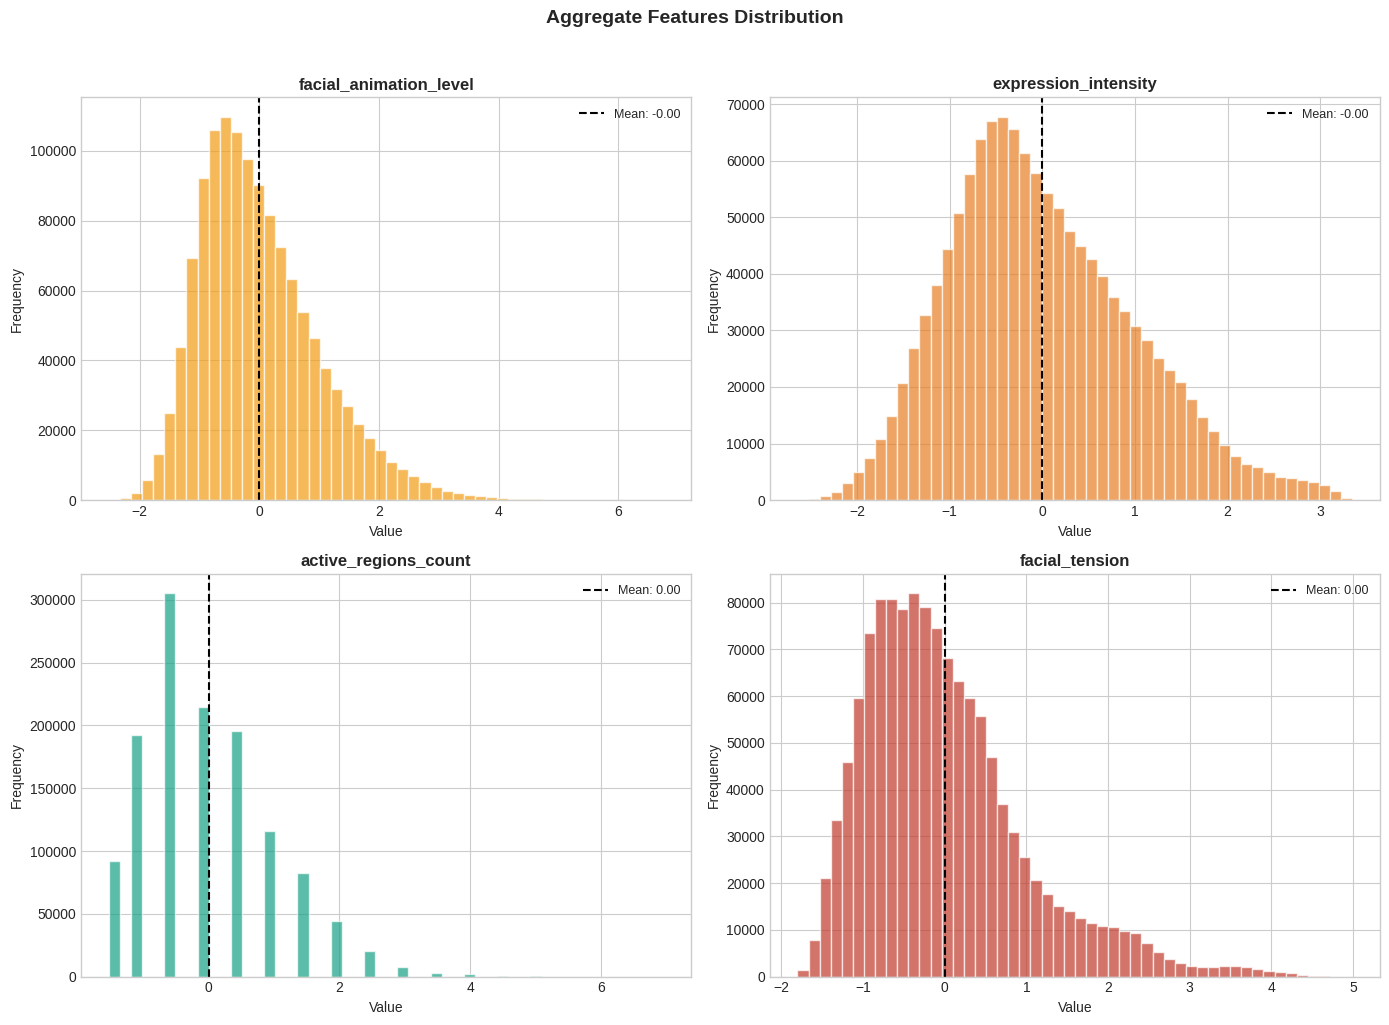

In [9]:
# Visualize Aggregate Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#f39c12', '#e67e22', '#16a085', '#c0392b']

for idx, (ax, feat_idx) in enumerate(zip(axes.flat, range(74, 78))):
    feature_data = X[:, :, feat_idx].flatten()
    ax.hist(feature_data, bins=50, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.set_title(f'{feature_names[feat_idx]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(feature_data), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(feature_data):.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Aggregate Features Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('aggregate_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Time Series Analysis

Let's visualize how features change over the 150 timesteps for a few sample videos.

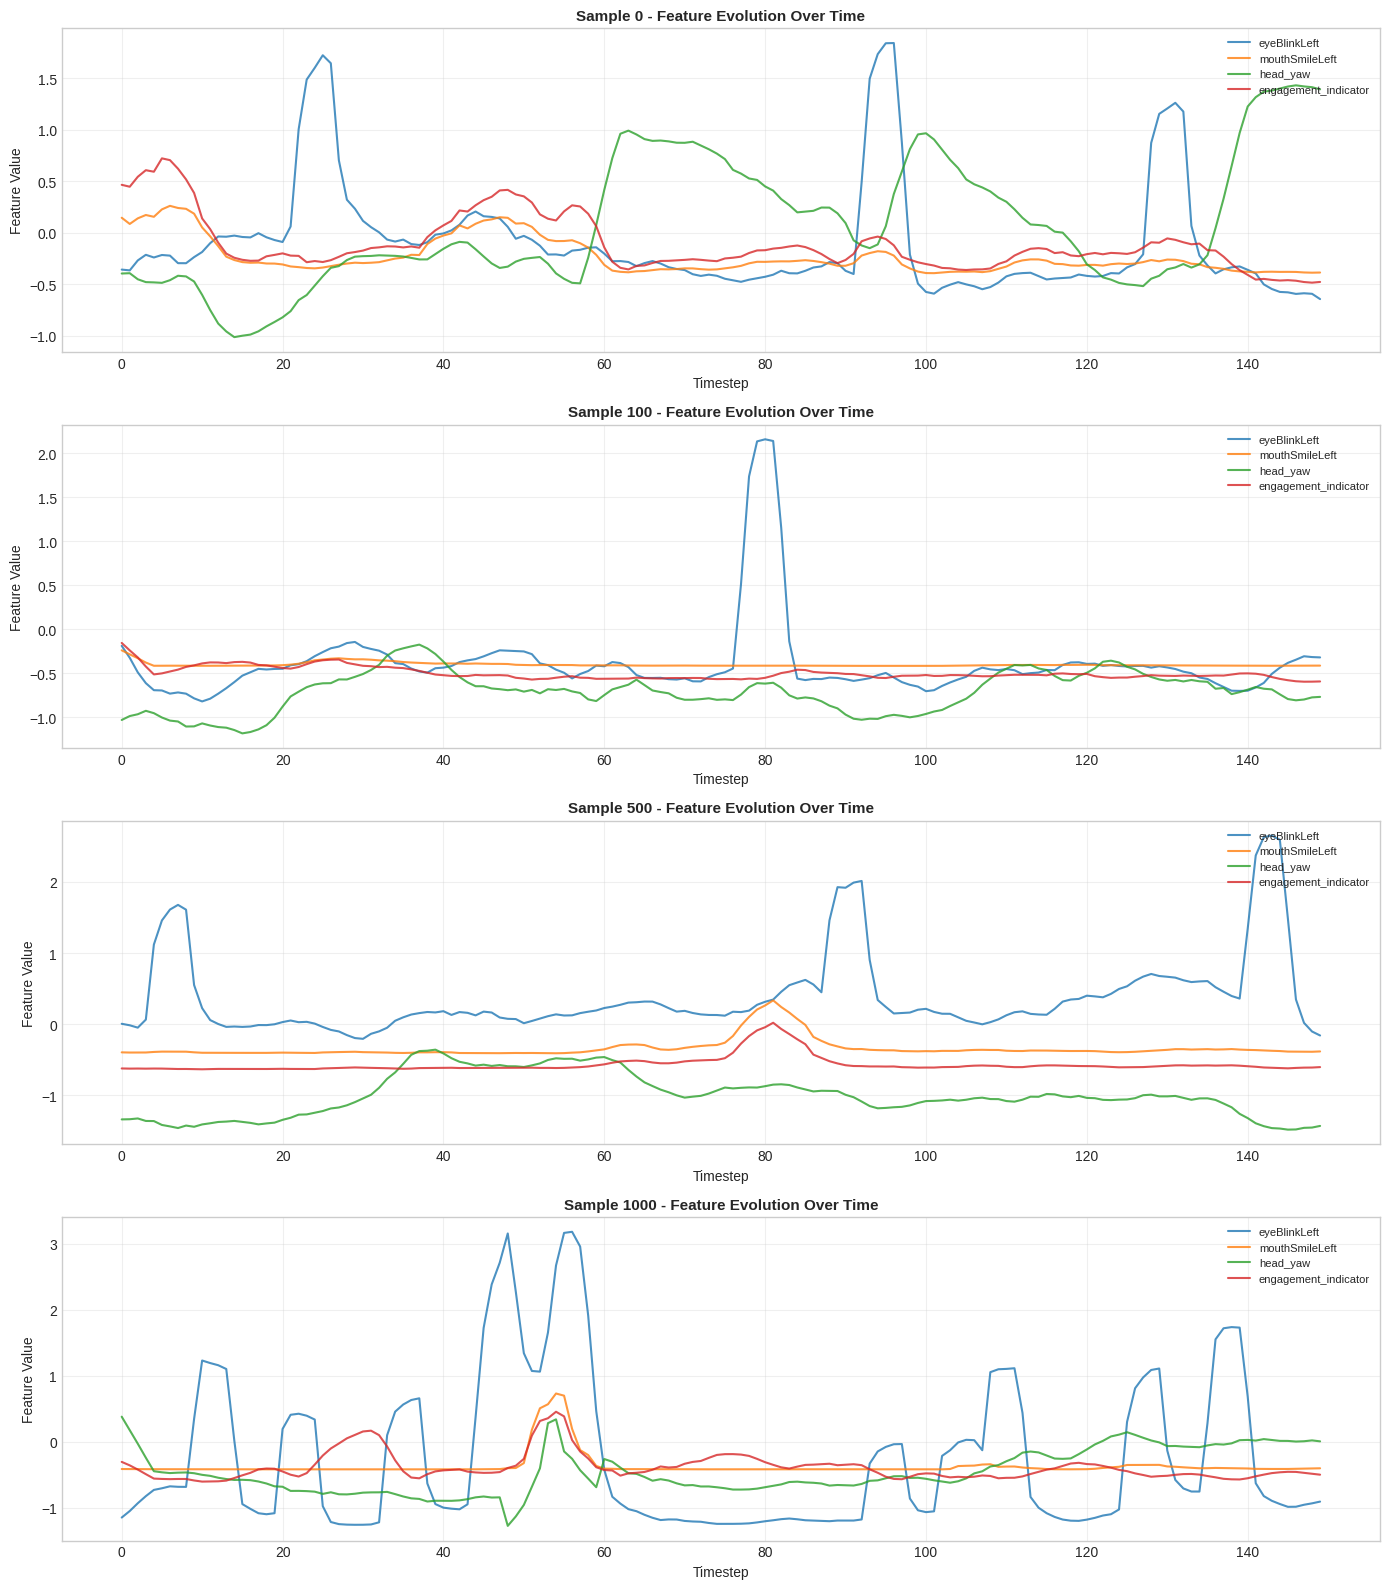

In [10]:
# Time series visualization for selected samples
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

sample_indices = [0, 100, 500, 1000]
key_features = ['eyeBlinkLeft', 'mouthSmileLeft', 'head_yaw', 'engagement_indicator']

for ax, sample_idx in zip(axes, sample_indices):
    for feat_name in key_features:
        feat_idx = feature_names.index(feat_name)
        ax.plot(X[sample_idx, :, feat_idx], label=feat_name, alpha=0.8)
    ax.set_title(f'Sample {sample_idx} - Feature Evolution Over Time', fontsize=11, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Feature Value')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Correlations

Understanding which features are correlated can help in feature selection and model building.

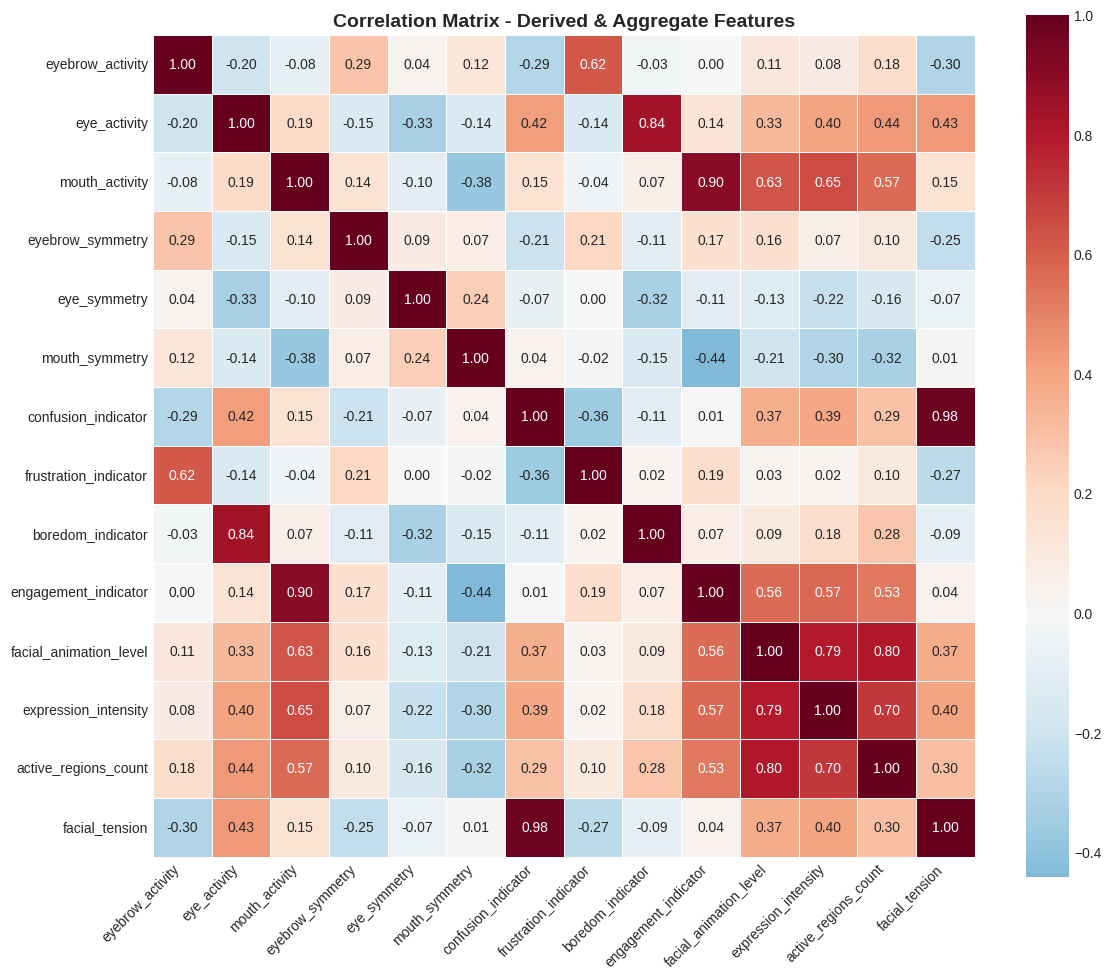

In [11]:
# Correlation matrix for aggregate/derived features
key_feature_indices = list(range(64, 78))
key_feature_names = [feature_names[i] for i in key_feature_indices]

# Compute correlation matrix (using subset for speed)
X_subset = X[:1000, :, :].reshape(-1, 78)
corr_matrix = np.corrcoef(X_subset[:, key_feature_indices].T)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=key_feature_names, yticklabels=key_feature_names,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Derived & Aggregate Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Statistics Summary

In [12]:
# Create summary statistics table
X_flat = X.reshape(-1, 78)

stats_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean': np.mean(X_flat, axis=0),
    'Std': np.std(X_flat, axis=0),
    'Min': np.min(X_flat, axis=0),
    'Max': np.max(X_flat, axis=0),
    'Q25': np.percentile(X_flat, 25, axis=0),
    'Q75': np.percentile(X_flat, 75, axis=0)
})

print("Feature Statistics Summary:")
print("=" * 80)
print(stats_df.to_string(index=False))
print("\n")

# Save to CSV
stats_df.to_csv('feature_statistics.csv', index=False)
print("Statistics saved to feature_statistics.csv")

Feature Statistics Summary:
                 Feature          Mean      Std        Min        Max       Q25       Q75
                _neutral -5.953029e-08 0.999605  -1.042296  24.845272 -0.627263  0.254938
            browDownLeft  1.068601e-06 1.000335  -0.700682   6.084805 -0.626660  0.218537
           browDownRight  6.638061e-06 1.000263  -0.709384   5.964589 -0.639963  0.285521
             browInnerUp  2.295896e-05 0.999390  -0.565291   7.719188 -0.551386  0.070034
         browOuterUpLeft -1.176740e-06 0.999830  -0.969046   5.105491 -0.804906  0.546851
        browOuterUpRight -1.207068e-06 0.999923  -0.920152   7.715632 -0.755641  0.483455
               cheekPuff -4.880285e-07 0.999369  -0.402544  26.021837 -0.290295 -0.098819
         cheekSquintLeft -2.973666e-07 0.999548  -0.736449  25.372763 -0.519836  0.103669
        cheekSquintRight  4.632460e-07 0.999521  -0.786947  24.152437 -0.488373  0.078333
            eyeBlinkLeft  3.260364e-07 0.999598  -1.276379   6.724277 -0

## Feature Importance by Label

Let's see how feature distributions differ across different engagement levels.

/tmp/ipykernel_856424/1778195344.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(feature_by_label, labels=labels, patch_artist=True)
/tmp/ipykernel_856424/1778195344.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(feature_by_label, labels=labels, patch_artist=True)
/tmp/ipykernel_856424/1778195344.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(feature_by_label, labels=labels, patch_artist=True)
/tmp/ipykernel_856424/1778195344.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; supp

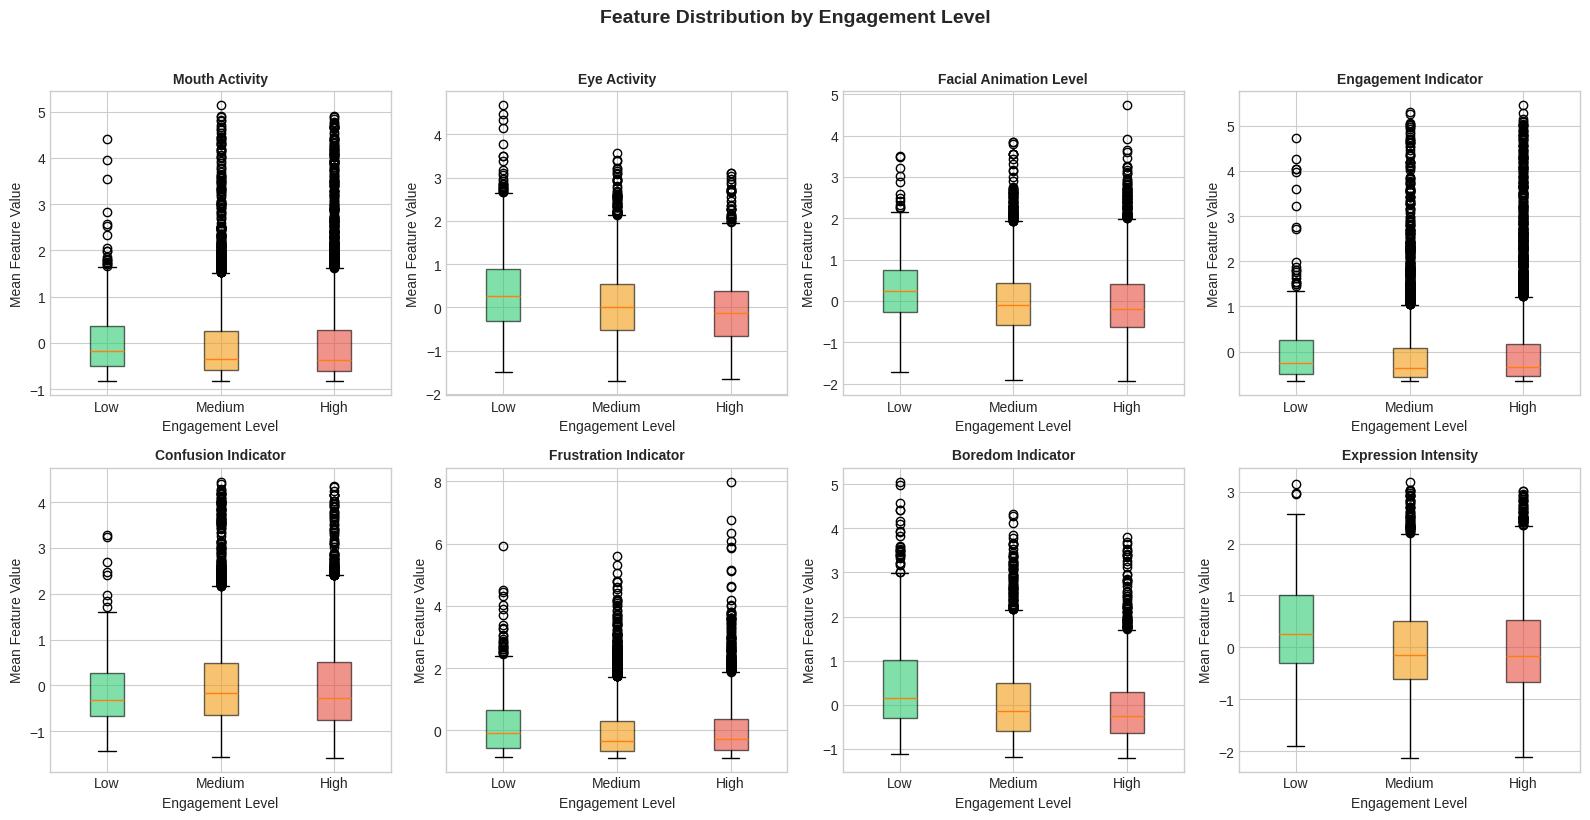

In [13]:
# Compare key features across engagement levels
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

compare_features = ['mouth_activity', 'eye_activity', 'facial_animation_level', 'engagement_indicator',
                   'confusion_indicator', 'frustration_indicator', 'boredom_indicator', 'expression_intensity']

for idx, (ax, feat_name) in enumerate(zip(axes.flat, compare_features)):
    feat_idx = feature_names.index(feat_name)
    feature_by_label = []
    labels = ['Low', 'Medium', 'High']
    for label_val in [0, 1, 2]:
        mask = y['engagement'] == label_val
        feature_vals = X[mask, :, feat_idx].mean(axis=1)
        feature_by_label.append(feature_vals)
    
    bp = ax.boxplot(feature_by_label, labels=labels, patch_artist=True)
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(feat_name.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Engagement Level')
    ax.set_ylabel('Mean Feature Value')

plt.suptitle('Feature Distribution by Engagement Level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('features_by_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Insights

1. **Dataset Balance**: The dataset is imbalanced for some labels:
   - Confusion: 67.3% Low, 23.1% Medium, 9.6% High
   - Frustration: 77.4% Low, 17.8% Medium, 4.8% High
   - Engagement is better balanced: 5.7% Low, 50.4% Medium, 43.9% High

2. **Feature Normalization**: All features appear to be normalized (z-score standardized), with mean ≈ 0 and std ≈ 1.

3. **Action Units**: Most facial action units have values close to 0 (neutral), with occasional spikes for active expressions.

4. **Head Pose & Gaze**: These features capture head orientation and eye gaze, which are important for detecting attention and engagement.

5. **Symmetry Features**: Negative values indicate asymmetric expressions, which can signal genuine vs. posed emotions.

6. **Engagement Indicators**: These derived features can help in directly predicting engagement levels.

## Conclusion

This notebook has provided a comprehensive overview of the DAISEE dataset:

- **8,503 samples** with **150 timesteps** each
- **78 features** covering facial expressions, head pose, gaze, and derived metrics
- **4 target labels** for engagement detection

The data is ready for training deep learning models (LSTM, Transformer, etc.) for multi-label engagement prediction.